> ⚠️ **LEGACY — fixed-τ 1BQF artefact (bannered 2026-07-06).** Any 1BQF (quantum)
> efficiency / false-rate in this notebook is computed at the **fixed τ=0.35 cut**, which
> pins the 1BQF at an artefactual **~70–75 % efficiency** (the cut chops the halved
> outer-true amplitude band — *the cut, not lost physics*). The project headline
> convention is **wp99** (efficiency-first working point; `Toy_Characterisation/WP99_REFRESH_LOG.md`).
> **Canonical replacement: `ERF/step_vs_erf_store.py` (metrics) and `ERF/erf_spectrum_classical.py` (spectral).** Kept as a historical record; not maintained.

# ERF vs Step-Function Hamiltonian: Local Comparison Study

Compares the ERF-smoothed Hamiltonian (`convolution=True`) against the hard
step-function baseline (`convolution=False`) on a fixed T=50 event with 5
detector layers.

**Sections**
- §1  Clean event (σ_scatt=0, σ_res=0, no noise) — eigenspectrum, solution vectors, metrics
- §2  Same event with 1% hit inefficiency — how do results shift?
- §3  Sigma scan over (σ_scatt, σ_res) grids

**Reference baseline (Verify_new_results):** T=50, step-function, eff=98.23 %, FAR=0.03 %


In [1]:
import sys, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.sparse.linalg import eigsh

HERE   = Path('.').resolve()
SHARED = (HERE / '../_shared').resolve()
sys.path.insert(0, str(SHARED))

from lhcb_velo_toy.solvers import SimpleHamiltonianFast
from lhcb_velo_toy.analysis import compute_epsilon
from lhcb_velo_toy.analysis.segment_metrics import fast_segment_metrics
from helpers import (make_geometry, safe_generate, apply_hit_inefficiency,
                     solve_quantum_statevector, rescale_quantum,
                     segment_truth_mask, solver_segment_metrics)

FIGURES = HERE / 'figures'
FIGURES.mkdir(exist_ok=True)

# Physics constants — match Verify_new_results §14e exactly
EPSILON      = 2e-3
GAMMA        = 3.0
DELTA        = 1.0
TAU              = 0.35   # legacy alias (unused for metrics)
SOLVER_THRESHOLD = 0.35   # ABSOLUTE seg threshold — matches segment_level_analysis.ipynb §14.
                          # Hopfield attractor (false/isolated) = delta/(delta+gamma) = 0.25;
                          # true segments sit on the ~0.375 plateau. 0.35 separates them.
T            = 50     # main event
T_EIGS       = 20     # dense eigvalsh feasible: n_seg ~ 1600 → < 1 s
T_QC         = 10     # quantum comparison: feasible on CPU statevector

SEED         = T      * 100 + 200_000   # 205 000
SEED_EIGS    = T_EIGS * 100 + 200_000   # 202 000
SEED_QC      = T_QC   * 100 + 200_000   # 201 000

THETA_D_GRID = [1e-6, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3]
TD_REPR      = [1e-6, 1e-4, 1e-3]   # three representative theta_d values

# Verify_new_results T=50 baseline (step-function, hit_ineff=0.01)
BASELINE = {"efficiency": 0.9823, "false_rate": 0.0003, "purity": 0.985}

geom = make_geometry()   # 5 modules, DZ=33 mm

# One-time Numba JIT warmup
_w = safe_generate(5, seed=99999, geom=geom,
                   measurement_error=0.0, collision_noise=1e-5)
fast_segment_metrics(_w, 1e-3)
print("JIT warmup complete")
print(f"Geometry: {len(geom)} modules | EPSILON={EPSILON:.1e} | T={T}")


The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


JIT warmup complete
Geometry: 5 modules | EPSILON=2.0e-03 | T=50


In [2]:
# =============================================================
# §1a  T=50 clean event + all Hamiltonians
# =============================================================
print(f"[§1a] Generating clean T={T} event (sigma_scatt=0, sigma_res=0, hit_ineff=0)...")
t0 = time.time()
ev_clean = safe_generate(T, seed=SEED, geom=geom,
                          measurement_error=0.0, collision_noise=0.0)
print(f"  n_hits={len(ev_clean.hits)}  [{time.time()-t0:.2f}s]")

# Step-function Hamiltonian (convolution=False)
print("Building step-function Hamiltonian...")
t0 = time.time()
ham_step = SimpleHamiltonianFast(epsilon=EPSILON, gamma=GAMMA, delta=DELTA, theta_d=1e-6)
ham_step.construct_segments(ev_clean)
ham_step.construct_hamiltonian(ev_clean, convolution=False)
sol_step   = np.asarray(ham_step.solve_classicaly()).ravel()
truth_step = segment_truth_mask(ham_step)
n_seg      = ham_step.n_segments
print(f"  n_seg={n_seg}  nnz={ham_step.A.nnz}  "
      f"n_true={truth_step.sum()}  n_false={(~truth_step).sum()}  [{time.time()-t0:.2f}s]")

# ERF Hamiltonians for all theta_d
print("Building ERF Hamiltonians...")
hams_erf, sols_erf, truths_erf = {}, {}, {}
for td in THETA_D_GRID:
    t0 = time.time()
    h = SimpleHamiltonianFast(epsilon=EPSILON, gamma=GAMMA, delta=DELTA, theta_d=td)
    h.construct_segments(ev_clean)
    h.construct_hamiltonian(ev_clean, convolution=True)
    hams_erf[td]   = h
    sols_erf[td]   = np.asarray(h.solve_classicaly()).ravel()
    truths_erf[td] = segment_truth_mask(h)
    print(f"  theta_d={td:.0e}: n_seg={h.n_segments}  nnz={h.A.nnz}  [{time.time()-t0:.2f}s]")

print("Done.")


[§1a] Generating clean T=50 event (sigma_scatt=0, sigma_res=0, hit_ineff=0)...
  n_hits=250  [0.00s]
Building step-function Hamiltonian...
  n_seg=10000  nnz=10300  n_true=200  n_false=9800  [0.02s]
Building ERF Hamiltonians...
  theta_d=1e-06: n_seg=10000  nnz=760000  [0.11s]


  theta_d=1e-05: n_seg=10000  nnz=760000  [0.22s]
  theta_d=5e-05: n_seg=10000  nnz=760000  [0.08s]
  theta_d=1e-04: n_seg=10000  nnz=760000  [0.09s]


  theta_d=5e-04: n_seg=10000  nnz=760000  [0.09s]
  theta_d=1e-03: n_seg=10000  nnz=760000  [0.10s]
Done.


In [3]:
# =============================================================
# §1a-eigs  T=20 event + full eigenspectrum via dense eigvalsh
# n_seg ~ 1 600 at T=20  →  eigvalsh completes in < 1 s
# =============================================================
print(f"[§1a-eigs] Generating T={T_EIGS} event for eigenspectrum...")
t0 = time.time()
ev_eigs = safe_generate(T_EIGS, seed=SEED_EIGS, geom=geom,
                         measurement_error=0.0, collision_noise=0.0)
print(f"  n_hits={len(ev_eigs.hits)}  [{time.time()-t0:.2f}s]")

he_step = SimpleHamiltonianFast(epsilon=EPSILON, gamma=GAMMA, delta=DELTA, theta_d=1e-6)
he_step.construct_segments(ev_eigs)
he_step.construct_hamiltonian(ev_eigs, convolution=False)
n_seg_e = he_step.n_segments
print(f"  Step: n_seg={n_seg_e}  nnz={he_step.A.nnz}")

hes_erf = {}
for td in THETA_D_GRID:
    h = SimpleHamiltonianFast(epsilon=EPSILON, gamma=GAMMA, delta=DELTA, theta_d=td)
    h.construct_segments(ev_eigs)
    h.construct_hamiltonian(ev_eigs, convolution=True)
    hes_erf[td] = h
    print(f"  ERF td={td:.0e}: nnz={h.A.nnz}")

print("Computing eigenspectra (dense eigvalsh)...")
t0 = time.time()
eigs_step_clean = np.linalg.eigvalsh(he_step.A.toarray())
eigs_erf_clean  = {td: np.linalg.eigvalsh(hes_erf[td].A.toarray())
                   for td in THETA_D_GRID}
kappa_step_clean = (eigs_step_clean.max()
                    / max(float(eigs_step_clean.min()), 1e-15))
kappas_erf_clean = {
    td: (eigs_erf_clean[td].max()
         / max(float(eigs_erf_clean[td].min()), 1e-15))
    for td in THETA_D_GRID
}
print(f"  kappa_step = {kappa_step_clean:.2f}  [{time.time()-t0:.2f}s]")
for td in THETA_D_GRID:
    print(f"  kappa_erf(td={td:.0e}) = {kappas_erf_clean[td]:.2f}")


[§1a-eigs] Generating T=20 event for eigenspectrum...
  n_hits=100  [0.00s]
  Step: n_seg=1600  nnz=1720
  ERF td=1e-06: nnz=49600
  ERF td=1e-05: nnz=49600
  ERF td=5e-05: nnz=49600
  ERF td=1e-04: nnz=49600
  ERF td=5e-04: nnz=49600
  ERF td=1e-03: nnz=49600
Computing eigenspectra (dense eigvalsh)...


  kappa_step = 2.36  [1.41s]
  kappa_erf(td=1e-06) = 9.47
  kappa_erf(td=1e-05) = 9.47
  kappa_erf(td=5e-05) = 9.47
  kappa_erf(td=1e-04) = 9.47
  kappa_erf(td=5e-04) = 9.47
  kappa_erf(td=1e-03) = 8.55


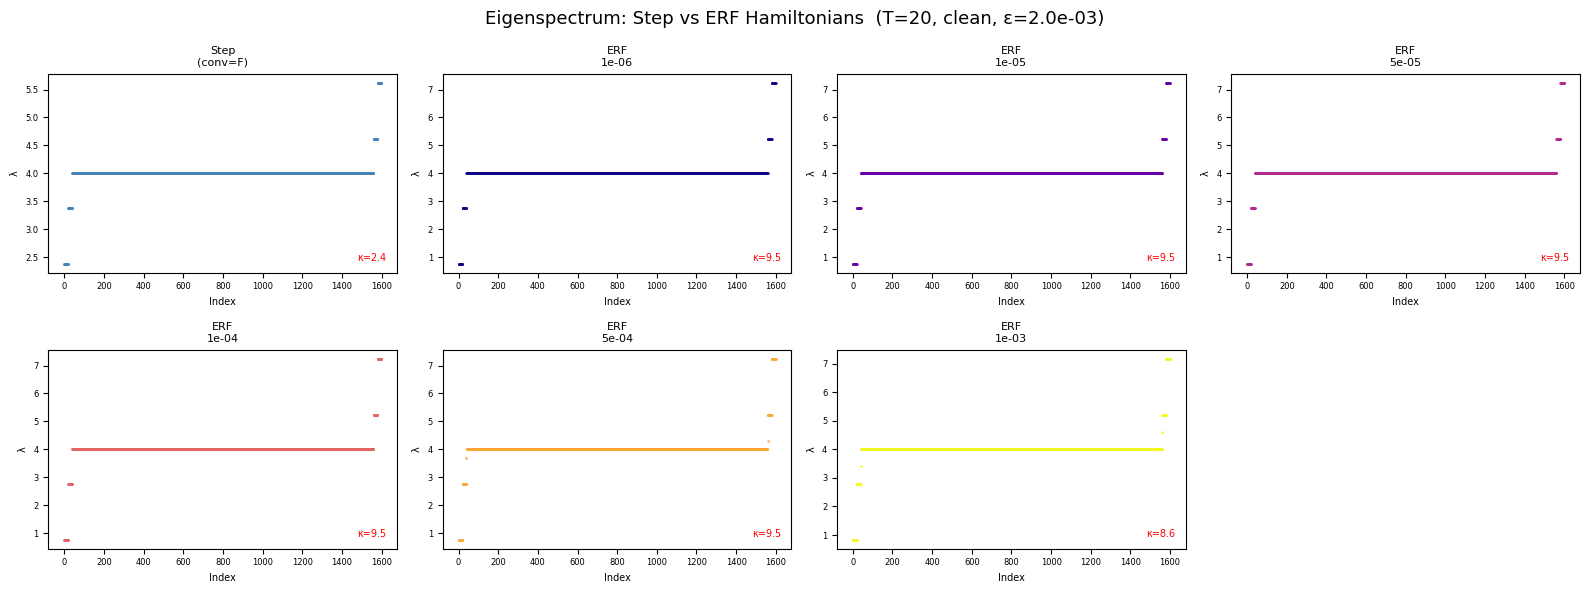

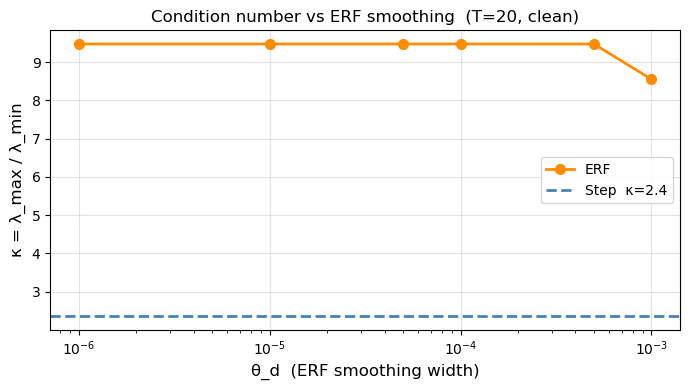

Saved eigspectrum_step_vs_erf_clean.png  kappa_vs_td_clean.png


In [4]:
# =============================================================
# §1b  Eigenspectrum comparison figure (T=20, clean)
# =============================================================
labels_all  = ['Step\n(conv=F)'] + [f'ERF\n{td:.0e}' for td in THETA_D_GRID]
eigs_all    = [eigs_step_clean] + [eigs_erf_clean[td] for td in THETA_D_GRID]
kappas_all  = [kappa_step_clean] + [kappas_erf_clean[td] for td in THETA_D_GRID]
colors_step = 'steelblue'
cmap        = plt.cm.plasma

# --- Sorted eigenvalue plots ---
n_panels = len(eigs_all)
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle(f'Eigenspectrum: Step vs ERF Hamiltonians  (T={T_EIGS}, clean, ε={EPSILON:.1e})',
             fontsize=13)

def _plot_sorted_eigs(ax, eigvals, title, color):
    s = np.sort(eigvals)
    ax.plot(range(len(s)), s, '.', color=color, ms=1.5)
    kap = s.max() / max(float(s.min()), 1e-15)
    ax.set_title(title, fontsize=8)
    ax.set_xlabel('Index', fontsize=7)
    ax.set_ylabel('λ', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.text(0.97, 0.05, f'κ={kap:.1f}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=7, color='red')

for idx, (lab, ev_, kap) in enumerate(zip(labels_all, eigs_all, kappas_all)):
    row, col = divmod(idx, 4)
    c = colors_step if idx == 0 else cmap((idx - 1) / max(len(THETA_D_GRID) - 1, 1))
    _plot_sorted_eigs(axes[row, col], ev_, lab, c)
# hide unused slot (panel 7, index 7 = row1 col3)
axes[1, 3].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES / 'eigspectrum_step_vs_erf_clean.png', dpi=150, bbox_inches='tight')
fig.savefig(FIGURES / 'eigspectrum_step_vs_erf_clean.pdf', bbox_inches='tight')
plt.show()

# --- Condition number vs theta_d ---
fig2, ax2 = plt.subplots(figsize=(7, 4))
kv = [kappas_erf_clean[td] for td in THETA_D_GRID]
ax2.semilogx(THETA_D_GRID, kv, 'o-', color='darkorange', lw=2, ms=7, label='ERF')
ax2.axhline(kappa_step_clean, ls='--', lw=2, color='steelblue',
            label=f'Step  κ={kappa_step_clean:.1f}')
ax2.set_xlabel('θ_d  (ERF smoothing width)', fontsize=12)
ax2.set_ylabel('κ = λ_max / λ_min', fontsize=12)
ax2.set_title(f'Condition number vs ERF smoothing  (T={T_EIGS}, clean)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.35)
plt.tight_layout()
fig2.savefig(FIGURES / 'kappa_vs_td_clean.png', dpi=150, bbox_inches='tight')
fig2.savefig(FIGURES / 'kappa_vs_td_clean.pdf', bbox_inches='tight')
plt.show()
print("Saved eigspectrum_step_vs_erf_clean.png  kappa_vs_td_clean.png")


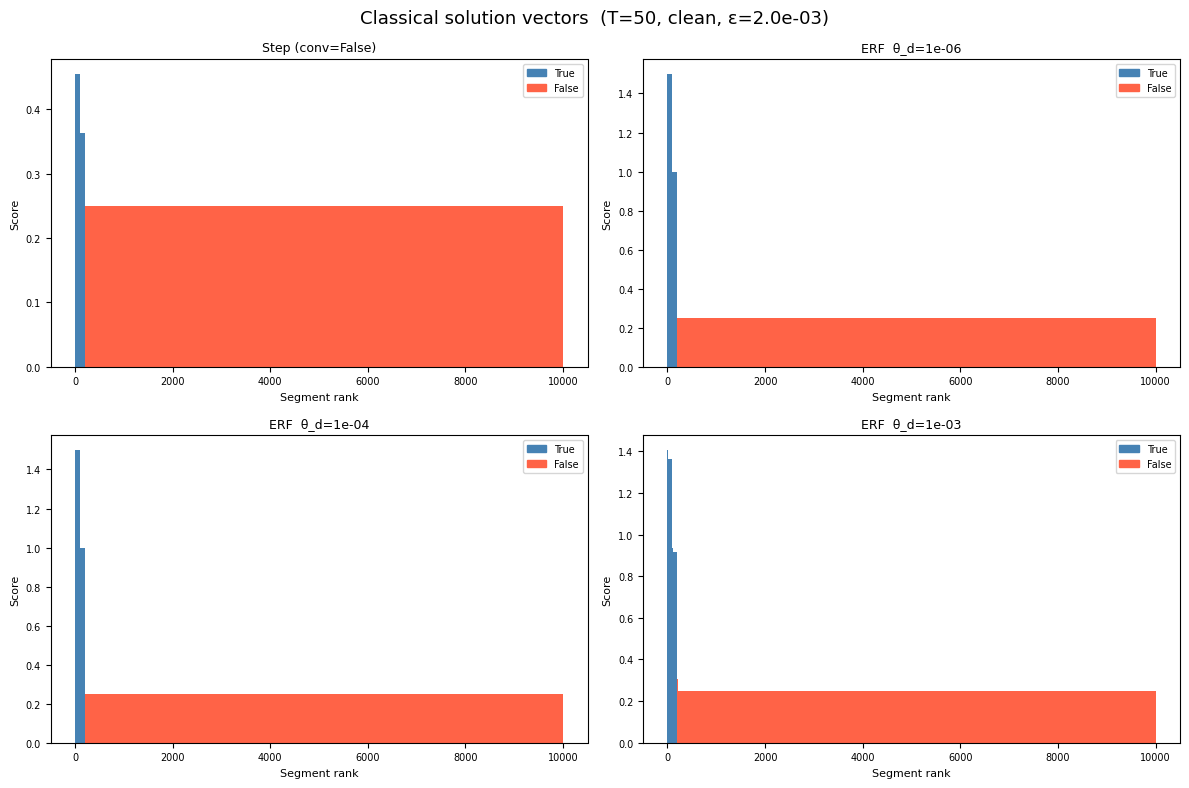

Saved sol_classical_clean.png


In [5]:
# =============================================================
# §1c  Solution vector comparison (T=50, classical, clean)
# Sorted activation spectrum coloured by truth (true=blue, false=red)
# =============================================================
def _plot_sol(ax, sol, truth, title):
    order = np.argsort(sol)[::-1]
    xs    = np.arange(len(sol))
    colors = np.where(truth[order], 'steelblue', 'tomato')
    ax.bar(xs, sol[order], color=colors, width=1.0, linewidth=0)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Segment rank', fontsize=8)
    ax.set_ylabel('Score', fontsize=8)
    ax.tick_params(labelsize=7)
    # legend proxies
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='steelblue', label='True'),
                        Patch(color='tomato',    label='False')],
              fontsize=7, loc='upper right')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f'Classical solution vectors  (T={T}, clean, ε={EPSILON:.1e})', fontsize=13)

panels = [('Step (conv=False)', sol_step, truth_step)] +          [(f'ERF  θ_d={td:.0e}', sols_erf[td], truths_erf[td]) for td in TD_REPR]

for ax, (title, sol, truth) in zip(axes.ravel(), panels):
    _plot_sol(ax, sol, truth, title)

plt.tight_layout()
fig.savefig(FIGURES / 'sol_classical_clean.png', dpi=150, bbox_inches='tight')
fig.savefig(FIGURES / 'sol_classical_clean.pdf', bbox_inches='tight')
plt.show()
print("Saved sol_classical_clean.png")


Metrics (clean T=50):
  Step          eff=1.0000  FAR=0.00000  pur=1.0000
  1e-06         eff=1.0000  FAR=0.00000  pur=1.0000
  1e-05         eff=1.0000  FAR=0.00000  pur=1.0000
  5e-05         eff=1.0000  FAR=0.00000  pur=1.0000
  1e-04         eff=1.0000  FAR=0.00000  pur=1.0000
  5e-04         eff=1.0000  FAR=0.00000  pur=1.0000
  1e-03         eff=1.0000  FAR=0.00000  pur=1.0000


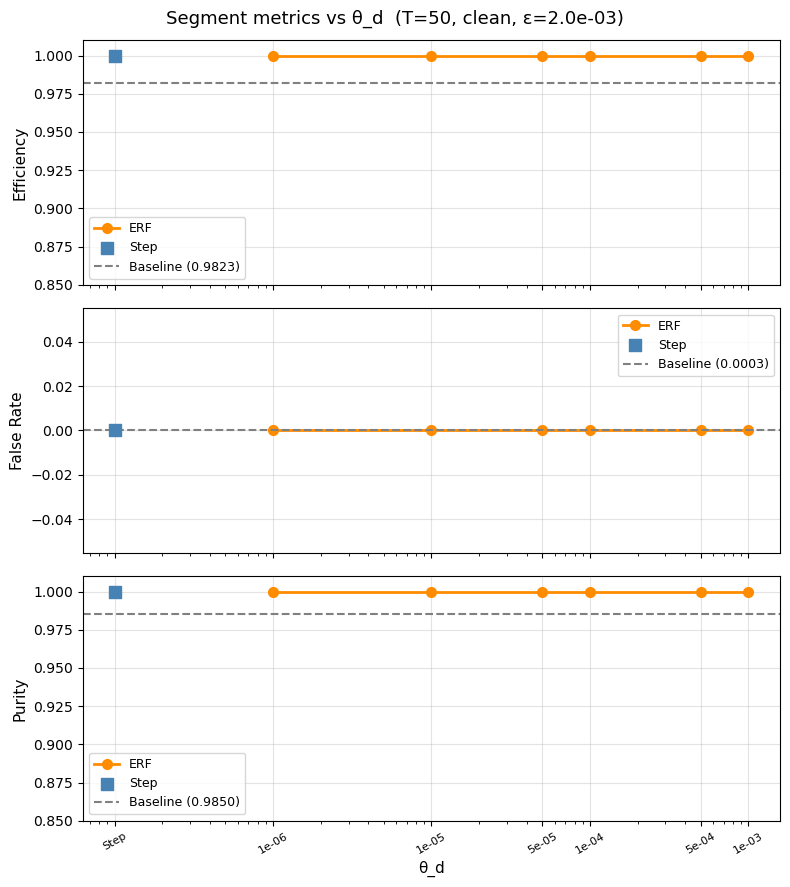

Saved seg_metrics_clean.png


In [6]:
# =============================================================
# §1d  Segment metrics vs theta_d  (T=50, clean)
# =============================================================
def _metrics(sol, truth):
    # ABSOLUTE threshold (matches baseline segment_level_analysis.ipynb §14):
    # false/isolated segments sit at the 0.25 Hopfield attractor; true segments
    # on the ~0.375 plateau. SOLVER_THRESHOLD=0.35 cuts cleanly between them.
    # (A RELATIVE threshold tau*max collapses below both levels -> FAR explosion.)
    return solver_segment_metrics(truth, sol, threshold=SOLVER_THRESHOLD)

# Collect: step as anchor + ERF sweep
td_plot   = [1e-7] + THETA_D_GRID            # 1e-7 = visual anchor for step
lab_plot  = ['Step'] + [f'{td:.0e}' for td in THETA_D_GRID]
eff_plot, far_plot, pur_plot = [], [], []

m_step = _metrics(sol_step, truth_step)
eff_plot.append(m_step['segment_efficiency'])
far_plot.append(m_step['segment_false_rate'])
pur_plot.append(m_step['segment_purity'])

for td in THETA_D_GRID:
    m = _metrics(sols_erf[td], truths_erf[td])
    eff_plot.append(m['segment_efficiency'])
    far_plot.append(m['segment_false_rate'])
    pur_plot.append(m['segment_purity'])

print("Metrics (clean T=50):")
for lab, e, f, p in zip(lab_plot, eff_plot, far_plot, pur_plot):
    print(f"  {lab:12s}  eff={e:.4f}  FAR={f:.5f}  pur={p:.4f}")

# ---- Figure ----
fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
fig.suptitle(f'Segment metrics vs θ_d  (T={T}, clean, ε={EPSILON:.1e})', fontsize=13)

for ax, yvals, ylabel, bl_key, ylim in zip(
        axes,
        [eff_plot, far_plot, pur_plot],
        ['Efficiency', 'False Rate', 'Purity'],
        ['efficiency', 'false_rate', 'purity'],
        [(0.85, 1.01), (0, None), (0.85, 1.01)]):
    ax.semilogx(td_plot[1:], yvals[1:], 'o-', color='darkorange',
                lw=2, ms=7, label='ERF')
    ax.scatter([td_plot[0]], [yvals[0]], marker='s', s=80,
               color='steelblue', zorder=5, label='Step')
    ax.axhline(BASELINE[bl_key], ls='--', color='grey', lw=1.5,
               label=f'Baseline ({BASELINE[bl_key]:.4f})')
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.35)
    if ylim[1] is not None:
        ax.set_ylim(ylim)

axes[-1].set_xlabel('θ_d', fontsize=11)
# manually set x-ticks to show the step anchor label
axes[-1].set_xticks(td_plot)
axes[-1].set_xticklabels(lab_plot, rotation=30, fontsize=8)

plt.tight_layout()
fig.savefig(FIGURES / 'seg_metrics_clean.png', dpi=150, bbox_inches='tight')
fig.savefig(FIGURES / 'seg_metrics_clean.pdf', bbox_inches='tight')
plt.show()
print("Saved seg_metrics_clean.png")


[§1e] Generating T=10 event for quantum comparison...
  n_hits=50
  Building Step Hamiltonian...
    n_seg=400  Running quantum (CPU statevector)...


    cos_QC=0.4651  P_anc=0.0224  n_sys=9  [3.6s]
      classical: eff=1.000 FAR=0.0000 pur=1.000
      quantum  : eff=1.000 FAR=0.0000 pur=1.000
  Building ERF td=1e-4 Hamiltonian...
    n_seg=400  Running quantum (CPU statevector)...


    cos_QC=0.8436  P_anc=0.0224  n_sys=9  [1.5s]
      classical: eff=1.000 FAR=0.0000 pur=1.000
      quantum  : eff=1.000 FAR=0.0000 pur=1.000


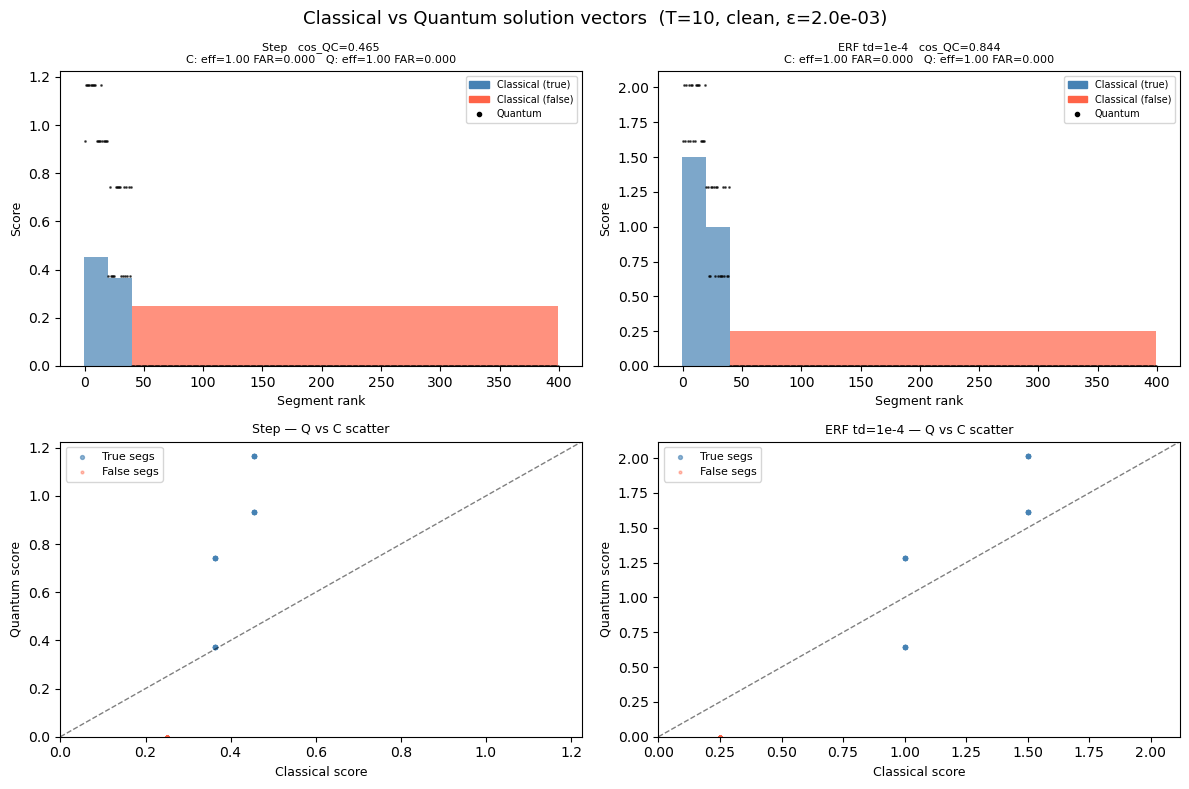

Saved quantum_comparison_clean_T10.png
NOTE: T=50 quantum (~10 000 segments) requires GPU/Condor; see ERF Condor results.


In [7]:
# =============================================================
# §1e  Quantum solution comparison  (T=10, CPU statevector)
# Compares classical vs quantum for step and ERF (td=1e-4)
# T=50 quantum requires GPU/Condor (~135 s on CPU)
# =============================================================
print(f"[§1e] Generating T={T_QC} event for quantum comparison...")
ev_qc = safe_generate(T_QC, seed=SEED_QC, geom=geom,
                       measurement_error=0.0, collision_noise=0.0)
print(f"  n_hits={len(ev_qc.hits)}")

results_qc = {}
for label, conv, td in [('Step', False, 1e-6), ('ERF td=1e-4', True, 1e-4)]:
    print(f"  Building {label} Hamiltonian...")
    h = SimpleHamiltonianFast(epsilon=EPSILON, gamma=GAMMA, delta=DELTA, theta_d=td)
    h.construct_segments(ev_qc)
    h.construct_hamiltonian(ev_qc, convolution=conv)
    sol_c = np.asarray(h.solve_classicaly()).ravel()
    truth = segment_truth_mask(h)
    n_seg_qc = h.n_segments
    print(f"    n_seg={n_seg_qc}  Running quantum (CPU statevector)...")
    t0 = time.time()
    sol_q_raw, P_anc, n_sys = solve_quantum_statevector(h.A, h.b, device='CPU')
    t_q = time.time() - t0
    sol_q = rescale_quantum(sol_q_raw, sol_c)
    cos_qc = float(np.dot(sol_q, sol_c)
                   / (np.linalg.norm(sol_q) * np.linalg.norm(sol_c) + 1e-30))
    # Segment metrics at the SAME absolute threshold (SOLVER_THRESHOLD=0.35) for
    # BOTH classical and the *rescaled* quantum solution. Identical rule to
    # segment_level_analysis.ipynb \u00a718a and segment_level_OneBQF.ipynb.
    mC = solver_segment_metrics(truth, sol_c, threshold=SOLVER_THRESHOLD)
    mQ = solver_segment_metrics(truth, sol_q, threshold=SOLVER_THRESHOLD)
    print(f"    cos_QC={cos_qc:.4f}  P_anc={P_anc:.4f}  n_sys={n_sys}  [{t_q:.1f}s]")
    print(f"      classical: eff={mC['segment_efficiency']:.3f} "
          f"FAR={mC['segment_false_rate']:.4f} pur={mC['segment_purity']:.3f}")
    print(f"      quantum  : eff={mQ['segment_efficiency']:.3f} "
          f"FAR={mQ['segment_false_rate']:.4f} pur={mQ['segment_purity']:.3f}")
    results_qc[label] = dict(sol_c=sol_c, sol_q=sol_q, truth=truth, cos_qc=cos_qc,
                             P_anc=P_anc, n_sys=n_sys, n_seg=n_seg_qc,
                             mC=mC, mQ=mQ)

# ---- Figure ----
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f'Classical vs Quantum solution vectors  (T={T_QC}, clean, ε={EPSILON:.1e})',
             fontsize=13)

for col, (label, res) in enumerate(results_qc.items()):
    sol_c = res['sol_c']
    sol_q = res['sol_q']
    truth = res['truth']
    order = np.argsort(sol_c)[::-1]

    # Top row: sorted classical (blue/red) with quantum overlay (black dots)
    ax = axes[0, col]
    xs = np.arange(len(sol_c))
    colors = np.where(truth[order], 'steelblue', 'tomato')
    ax.bar(xs, sol_c[order], color=colors, width=1.0, linewidth=0, alpha=0.7)
    ax.plot(xs, sol_q[order], 'k.', ms=2, alpha=0.6, label='Quantum')
    _mC, _mQ = res["mC"], res["mQ"]
    ax.set_title(f'{label}   cos_QC={res["cos_qc"]:.3f}\n'
                 f'C: eff={_mC["segment_efficiency"]:.2f} FAR={_mC["segment_false_rate"]:.3f}   '
                 f'Q: eff={_mQ["segment_efficiency"]:.2f} FAR={_mQ["segment_false_rate"]:.3f}',
                 fontsize=8)
    ax.set_xlabel('Segment rank', fontsize=9)
    ax.set_ylabel('Score', fontsize=9)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='steelblue', label='Classical (true)'),
                        Patch(color='tomato',    label='Classical (false)'),
                        plt.Line2D([0],[0], marker='.', color='k', ls='',
                                   ms=6, label='Quantum')],
              fontsize=7, loc='upper right')

    # Bottom row: quantum vs classical scatter
    ax2 = axes[1, col]
    ax2.scatter(sol_c[truth],  sol_q[truth],  s=8, c='steelblue', alpha=0.6, label='True segs')
    ax2.scatter(sol_c[~truth], sol_q[~truth], s=4, c='tomato',    alpha=0.4, label='False segs')
    lim = max(sol_c.max(), sol_q.max()) * 1.05
    ax2.plot([0, lim], [0, lim], 'k--', lw=1, alpha=0.5)
    ax2.set_xlim(0, lim); ax2.set_ylim(0, lim)
    ax2.set_xlabel('Classical score', fontsize=9)
    ax2.set_ylabel('Quantum score', fontsize=9)
    ax2.legend(fontsize=8)
    ax2.set_title(f'{label} — Q vs C scatter', fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES / 'quantum_comparison_clean_T10.png', dpi=150, bbox_inches='tight')
fig.savefig(FIGURES / 'quantum_comparison_clean_T10.pdf', bbox_inches='tight')
plt.show()
print("Saved quantum_comparison_clean_T10.png")
print("NOTE: T=50 quantum (~10 000 segments) requires GPU/Condor; see ERF Condor results.")


## §2  Noisy event — 1 % hit inefficiency

Same T=50 event, same seed, but with `apply_hit_inefficiency(p_drop=0.01)`.
Compares eigenspectrum and segment metrics against the clean §1 results.


In [8]:
# =============================================================
# §2a  Noisy event (hit_ineff=0.01) + all Hamiltonians
# =============================================================
HIT_INEFF = 0.01

print(f"[§2a] Generating T={T} event then dropping {HIT_INEFF*100:.0f}% hits...")
t0 = time.time()
ev_noisy = safe_generate(T, seed=SEED, geom=geom,
                          measurement_error=0.0, collision_noise=0.0)
apply_hit_inefficiency(ev_noisy, p_drop=HIT_INEFF,
                        rng=np.random.default_rng(SEED + 31))
print(f"  n_hits_after_drop={len(ev_noisy.hits)}  [{time.time()-t0:.2f}s]")

print("Building step-function Hamiltonian (noisy)...")
t0 = time.time()
ham_step_n = SimpleHamiltonianFast(epsilon=EPSILON, gamma=GAMMA, delta=DELTA, theta_d=1e-6)
ham_step_n.construct_segments(ev_noisy)
ham_step_n.construct_hamiltonian(ev_noisy, convolution=False)
sol_step_n   = np.asarray(ham_step_n.solve_classicaly()).ravel()
truth_step_n = segment_truth_mask(ham_step_n)
print(f"  n_seg={ham_step_n.n_segments}  [{time.time()-t0:.2f}s]")

print("Building ERF Hamiltonians (noisy)...")
hams_erf_n, sols_erf_n, truths_erf_n = {}, {}, {}
for td in THETA_D_GRID:
    t0 = time.time()
    h = SimpleHamiltonianFast(epsilon=EPSILON, gamma=GAMMA, delta=DELTA, theta_d=td)
    h.construct_segments(ev_noisy)
    h.construct_hamiltonian(ev_noisy, convolution=True)
    hams_erf_n[td]   = h
    sols_erf_n[td]   = np.asarray(h.solve_classicaly()).ravel()
    truths_erf_n[td] = segment_truth_mask(h)
    print(f"  theta_d={td:.0e}: n_seg={h.n_segments}  [{time.time()-t0:.2f}s]")

print("Done.")


[§2a] Generating T=50 event then dropping 1% hits...
  n_hits_after_drop=250  [0.00s]
Building step-function Hamiltonian (noisy)...
  n_seg=10000  [0.02s]
Building ERF Hamiltonians (noisy)...
  theta_d=1e-06: n_seg=10000  [0.09s]


  theta_d=1e-05: n_seg=10000  [0.08s]


  theta_d=5e-05: n_seg=10000  [0.08s]
  theta_d=1e-04: n_seg=10000  [0.09s]


  theta_d=5e-04: n_seg=10000  [0.09s]


  theta_d=1e-03: n_seg=10000  [0.10s]
Done.


In [9]:
# =============================================================
# §2a-eigs  T=20 noisy event for eigenspectrum
# =============================================================
print(f"[§2a-eigs] Generating T={T_EIGS} noisy event...")
ev_eigs_n = safe_generate(T_EIGS, seed=SEED_EIGS, geom=geom,
                            measurement_error=0.0, collision_noise=0.0)
apply_hit_inefficiency(ev_eigs_n, p_drop=HIT_INEFF,
                        rng=np.random.default_rng(SEED_EIGS + 31))
print(f"  n_hits={len(ev_eigs_n.hits)}")

he_step_n = SimpleHamiltonianFast(epsilon=EPSILON, gamma=GAMMA, delta=DELTA, theta_d=1e-6)
he_step_n.construct_segments(ev_eigs_n)
he_step_n.construct_hamiltonian(ev_eigs_n, convolution=False)
hes_erf_n = {}
for td in THETA_D_GRID:
    h = SimpleHamiltonianFast(epsilon=EPSILON, gamma=GAMMA, delta=DELTA, theta_d=td)
    h.construct_segments(ev_eigs_n)
    h.construct_hamiltonian(ev_eigs_n, convolution=True)
    hes_erf_n[td] = h

print("Computing eigenspectra (noisy)...")
t0 = time.time()
eigs_step_noisy = np.linalg.eigvalsh(he_step_n.A.toarray())
eigs_erf_noisy  = {td: np.linalg.eigvalsh(hes_erf_n[td].A.toarray())
                   for td in THETA_D_GRID}
kappa_step_noisy = (eigs_step_noisy.max()
                    / max(float(eigs_step_noisy.min()), 1e-15))
kappas_erf_noisy = {
    td: (eigs_erf_noisy[td].max()
         / max(float(eigs_erf_noisy[td].min()), 1e-15))
    for td in THETA_D_GRID
}
print(f"  kappa_step: clean={kappa_step_clean:.2f} -> noisy={kappa_step_noisy:.2f}  [{time.time()-t0:.2f}s]")
for td in THETA_D_GRID:
    print(f"  td={td:.0e}: clean={kappas_erf_clean[td]:.2f} -> noisy={kappas_erf_noisy[td]:.2f}")


[§2a-eigs] Generating T=20 noisy event...
  n_hits=95
Computing eigenspectra (noisy)...


  kappa_step: clean=2.36 -> noisy=2.36  [0.94s]
  td=1e-06: clean=9.47 -> noisy=9.47
  td=1e-05: clean=9.47 -> noisy=9.47
  td=5e-05: clean=9.47 -> noisy=9.47
  td=1e-04: clean=9.47 -> noisy=9.47
  td=5e-04: clean=9.47 -> noisy=9.47
  td=1e-03: clean=8.55 -> noisy=8.55


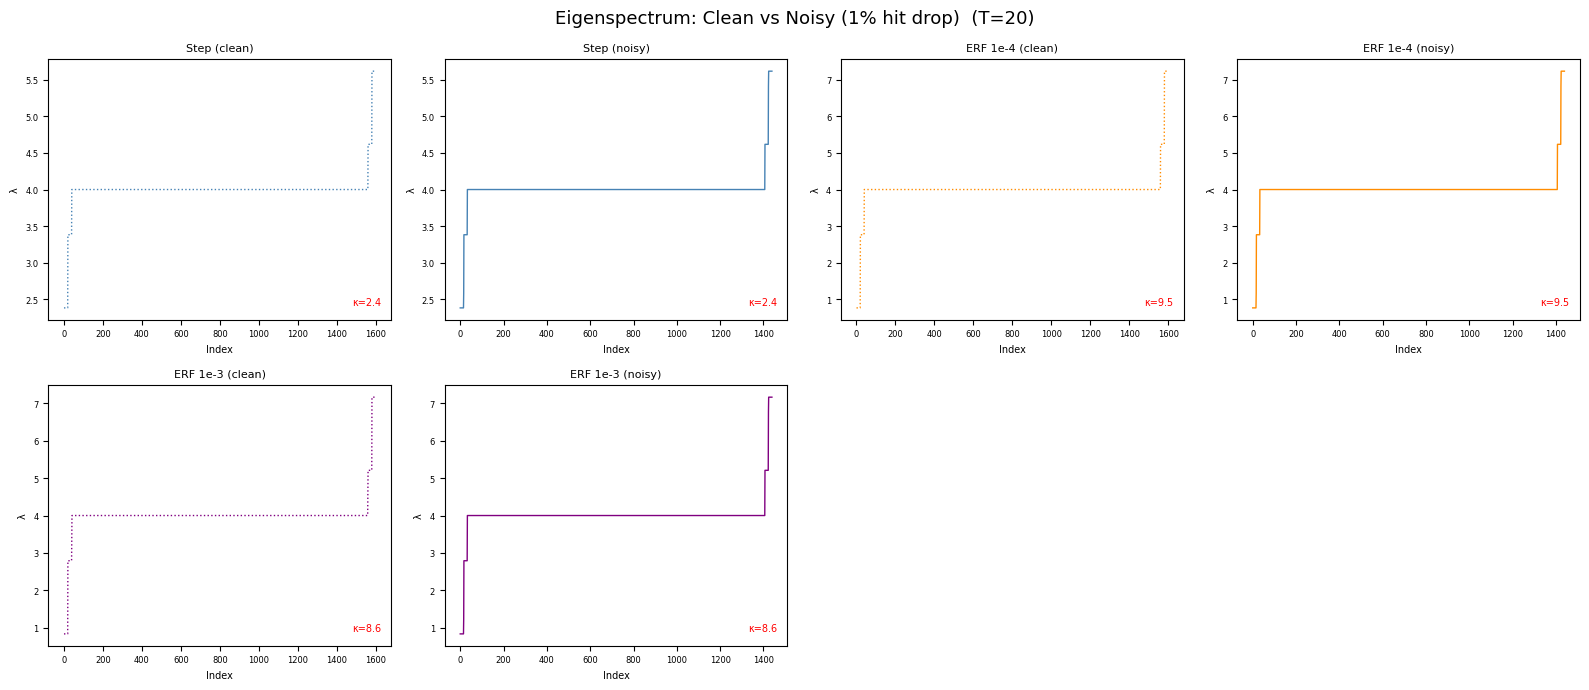

Saved eigspectrum_noise_delta.png


In [10]:
# =============================================================
# §2b  Eigenspectrum delta (clean vs noisy)  —  T=20
# =============================================================
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle(f'Eigenspectrum: Clean vs Noisy (1% hit drop)  (T={T_EIGS})', fontsize=13)

panels = [('Step (clean)',      eigs_step_clean,              'steelblue', ':'),
          ('Step (noisy)',      eigs_step_noisy,              'steelblue', '-'),
          ('ERF 1e-4 (clean)',  eigs_erf_clean[1e-4],        'darkorange',':'),
          ('ERF 1e-4 (noisy)',  eigs_erf_noisy[1e-4],        'darkorange','-'),
          ('ERF 1e-3 (clean)',  eigs_erf_clean[1e-3],        'purple',    ':'),
          ('ERF 1e-3 (noisy)',  eigs_erf_noisy[1e-3],        'purple',    '-')]

def _plot_eigs(ax, ev_, label, color, ls):
    s = np.sort(ev_)
    ax.plot(range(len(s)), s, color=color, lw=1.0, ls=ls, label=label, ms=1)
    kap = s.max() / max(float(s.min()), 1e-15)
    ax.set_title(label, fontsize=8)
    ax.set_xlabel('Index', fontsize=7); ax.set_ylabel('λ', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.text(0.97, 0.05, f'κ={kap:.1f}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=7, color='red')

for idx, (lab, ev_, col, ls) in enumerate(panels):
    row, col_ = divmod(idx, 4)
    if row < 2 and col_ < 4:
        _plot_eigs(axes[row, col_], ev_, lab, col, ls)
axes[1, 2].set_visible(False)
axes[1, 3].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES / 'eigspectrum_noise_delta.png', dpi=150, bbox_inches='tight')
fig.savefig(FIGURES / 'eigspectrum_noise_delta.pdf', bbox_inches='tight')
plt.show()
print("Saved eigspectrum_noise_delta.png")


Metrics (noisy T=50):
  Step          eff=1.0000  FAR=0.00000  pur=1.0000
  1e-06         eff=1.0000  FAR=0.01961  pur=0.9804
  1e-05         eff=1.0000  FAR=0.01961  pur=0.9804
  5e-05         eff=1.0000  FAR=0.01961  pur=0.9804
  1e-04         eff=1.0000  FAR=0.01961  pur=0.9804
  5e-04         eff=1.0000  FAR=0.01961  pur=0.9804
  1e-03         eff=1.0000  FAR=0.00990  pur=0.9901


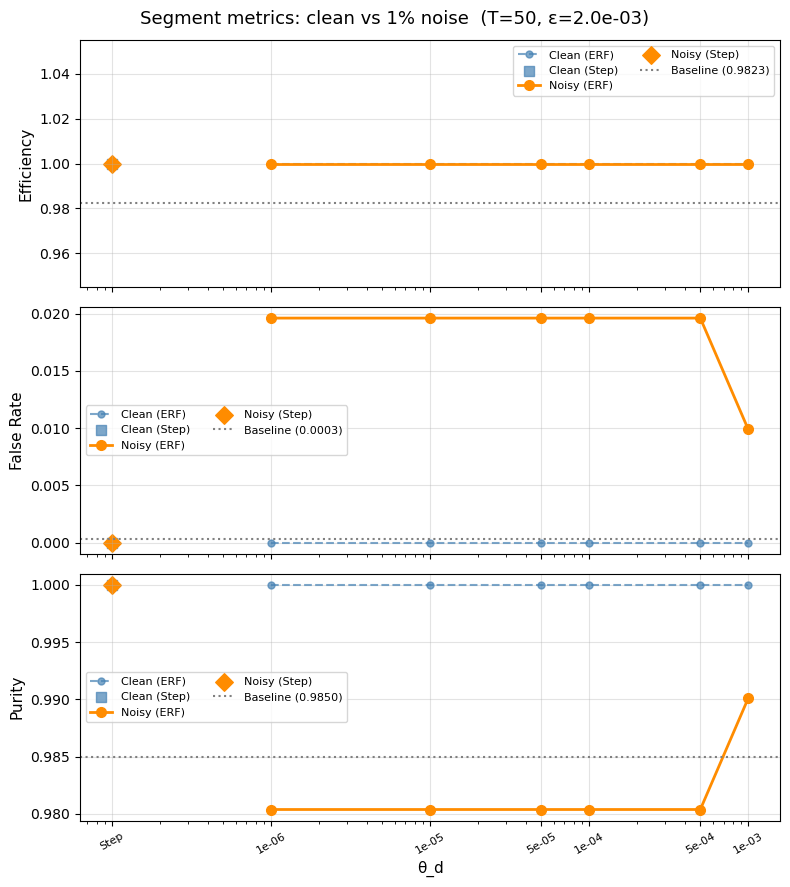

Saved seg_metrics_noisy.png


In [11]:
# =============================================================
# §2c  Segment metrics with noise  (T=50, overlaid on clean)
# =============================================================
eff_n, far_n, pur_n = [], [], []
m_step_n = _metrics(sol_step_n, truth_step_n)
eff_n.append(m_step_n['segment_efficiency'])
far_n.append(m_step_n['segment_false_rate'])
pur_n.append(m_step_n['segment_purity'])
for td in THETA_D_GRID:
    m = _metrics(sols_erf_n[td], truths_erf_n[td])
    eff_n.append(m['segment_efficiency'])
    far_n.append(m['segment_false_rate'])
    pur_n.append(m['segment_purity'])

print("Metrics (noisy T=50):")
for lab, e, f, p in zip(lab_plot, eff_n, far_n, pur_n):
    print(f"  {lab:12s}  eff={e:.4f}  FAR={f:.5f}  pur={p:.4f}")

fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
fig.suptitle(f'Segment metrics: clean vs 1% noise  (T={T}, ε={EPSILON:.1e})', fontsize=13)

for ax, (y_clean, y_noisy, ylabel, bl_key) in zip(
        axes,
        [(eff_plot, eff_n, 'Efficiency', 'efficiency'),
         (far_plot, far_n, 'False Rate', 'false_rate'),
         (pur_plot, pur_n, 'Purity',     'purity')]):
    ax.semilogx(td_plot[1:], y_clean[1:], 'o--', color='steelblue',
                lw=1.5, ms=5, alpha=0.7, label='Clean (ERF)')
    ax.scatter([td_plot[0]], [y_clean[0]], marker='s', s=60,
               color='steelblue', alpha=0.7, label='Clean (Step)')
    ax.semilogx(td_plot[1:], y_noisy[1:], 'o-', color='darkorange',
                lw=2, ms=7, label='Noisy (ERF)')
    ax.scatter([td_plot[0]], [y_noisy[0]], marker='D', s=80,
               color='darkorange', label='Noisy (Step)')
    ax.axhline(BASELINE[bl_key], ls=':', color='grey', lw=1.5,
               label=f'Baseline ({BASELINE[bl_key]:.4f})')
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=8, ncol=2, loc='best')
    ax.grid(True, alpha=0.35)

axes[-1].set_xlabel('θ_d', fontsize=11)
axes[-1].set_xticks(td_plot)
axes[-1].set_xticklabels(lab_plot, rotation=30, fontsize=8)

plt.tight_layout()
fig.savefig(FIGURES / 'seg_metrics_noisy.png', dpi=150, bbox_inches='tight')
fig.savefig(FIGURES / 'seg_metrics_noisy.pdf', bbox_inches='tight')
plt.show()
print("Saved seg_metrics_noisy.png")


## §3  Sigma scan — varying σ_scatt and σ_res

Fixed ε=2e-3 (matching Verify_new_results baseline) across all scan points.
Three Hamiltonians compared: step-function, ERF θ_d=1e-4, ERF θ_d=1e-3.


In [12]:
# =============================================================
# §3  Sigma scan  (T=50, fixed ε=2e-3)
# Grid: sigma_scatt × sigma_res
# Hamiltonians: step | ERF td=1e-4 | ERF td=1e-3
# =============================================================
SIGMA_SCATT_VALS = [0.0, 1e-4, 5e-4]
SIGMA_RES_VALS   = [0.0, 5e-6, 0.02]
SCAN_HAMS = [('step',      False, 1e-6),
             ('erf_1e-4',  True,  1e-4),
             ('erf_1e-3',  True,  1e-3)]

metrics_scan = {}
total = len(SIGMA_SCATT_VALS) * len(SIGMA_RES_VALS) * len(SCAN_HAMS)
done = 0

for ss in SIGMA_SCATT_VALS:
    for sr in SIGMA_RES_VALS:
        print(f"  Generating event ss={ss:.0e} sr={sr:.0e} ...")
        t0 = time.time()
        ev_s = safe_generate(T, seed=SEED, geom=geom,
                              measurement_error=float(sr),
                              collision_noise=float(ss))
        print(f"    n_hits={len(ev_s.hits)}  [{time.time()-t0:.2f}s]")
        for ham_key, conv, td in SCAN_HAMS:
            t0 = time.time()
            h = SimpleHamiltonianFast(epsilon=EPSILON, gamma=GAMMA,
                                       delta=DELTA, theta_d=td)
            h.construct_segments(ev_s)
            h.construct_hamiltonian(ev_s, convolution=conv)
            sol  = np.asarray(h.solve_classicaly()).ravel()
            truth = segment_truth_mask(h)
            m = _metrics(sol, truth)
            metrics_scan[(ss, sr, ham_key)] = m
            done += 1
            print(f"    [{done}/{total}] ({ss:.0e},{sr:.0e}) {ham_key}: "
                  f"eff={m['segment_efficiency']:.3f}  FAR={m['segment_false_rate']:.4f}")

print("Scan complete.")


  Generating event ss=0e+00 sr=0e+00 ...
    n_hits=250  [0.00s]


    [1/27] (0e+00,0e+00) step: eff=1.000  FAR=0.0099
    [2/27] (0e+00,0e+00) erf_1e-4: eff=1.000  FAR=0.0196
    [3/27] (0e+00,0e+00) erf_1e-3: eff=1.000  FAR=0.0291
  Generating event ss=0e+00 sr=5e-06 ...
    n_hits=250  [0.00s]


    [4/27] (0e+00,5e-06) step: eff=1.000  FAR=0.0000
    [5/27] (0e+00,5e-06) erf_1e-4: eff=1.000  FAR=0.0099
    [6/27] (0e+00,5e-06) erf_1e-3: eff=1.000  FAR=0.0000
  Generating event ss=0e+00 sr=2e-02 ...
    n_hits=250  [0.01s]
    [7/27] (0e+00,2e-02) step: eff=0.475  FAR=0.0000


    [8/27] (0e+00,2e-02) erf_1e-4: eff=0.660  FAR=0.0000
    [9/27] (0e+00,2e-02) erf_1e-3: eff=0.760  FAR=0.0000
  Generating event ss=1e-04 sr=0e+00 ...
    n_hits=250  [0.00s]
    [10/27] (1e-04,0e+00) step: eff=1.000  FAR=0.0000


    [11/27] (1e-04,0e+00) erf_1e-4: eff=1.000  FAR=0.0000
    [12/27] (1e-04,0e+00) erf_1e-3: eff=1.000  FAR=0.0000
  Generating event ss=1e-04 sr=5e-06 ...
    n_hits=250  [0.00s]
    [13/27] (1e-04,5e-06) step: eff=1.000  FAR=0.0000
    [14/27] (1e-04,5e-06) erf_1e-4: eff=1.000  FAR=0.0000


    [15/27] (1e-04,5e-06) erf_1e-3: eff=1.000  FAR=0.0000
  Generating event ss=1e-04 sr=2e-02 ...
    n_hits=250  [0.01s]
    [16/27] (1e-04,2e-02) step: eff=0.525  FAR=0.0000
    [17/27] (1e-04,2e-02) erf_1e-4: eff=0.700  FAR=0.0000


    [18/27] (1e-04,2e-02) erf_1e-3: eff=0.765  FAR=0.0000
  Generating event ss=5e-04 sr=0e+00 ...
    n_hits=250  [0.00s]
    [19/27] (5e-04,0e+00) step: eff=1.000  FAR=0.0000
    [20/27] (5e-04,0e+00) erf_1e-4: eff=1.000  FAR=0.0196


    [21/27] (5e-04,0e+00) erf_1e-3: eff=1.000  FAR=0.0099
  Generating event ss=5e-04 sr=5e-06 ...
    n_hits=250  [0.01s]
    [22/27] (5e-04,5e-06) step: eff=1.000  FAR=0.0000


    [23/27] (5e-04,5e-06) erf_1e-4: eff=1.000  FAR=0.0196
    [24/27] (5e-04,5e-06) erf_1e-3: eff=1.000  FAR=0.0148
  Generating event ss=5e-04 sr=2e-02 ...
    n_hits=250  [0.00s]
    [25/27] (5e-04,2e-02) step: eff=0.460  FAR=0.0000


    [26/27] (5e-04,2e-02) erf_1e-4: eff=0.765  FAR=0.0255
    [27/27] (5e-04,2e-02) erf_1e-3: eff=0.800  FAR=0.0123
Scan complete.


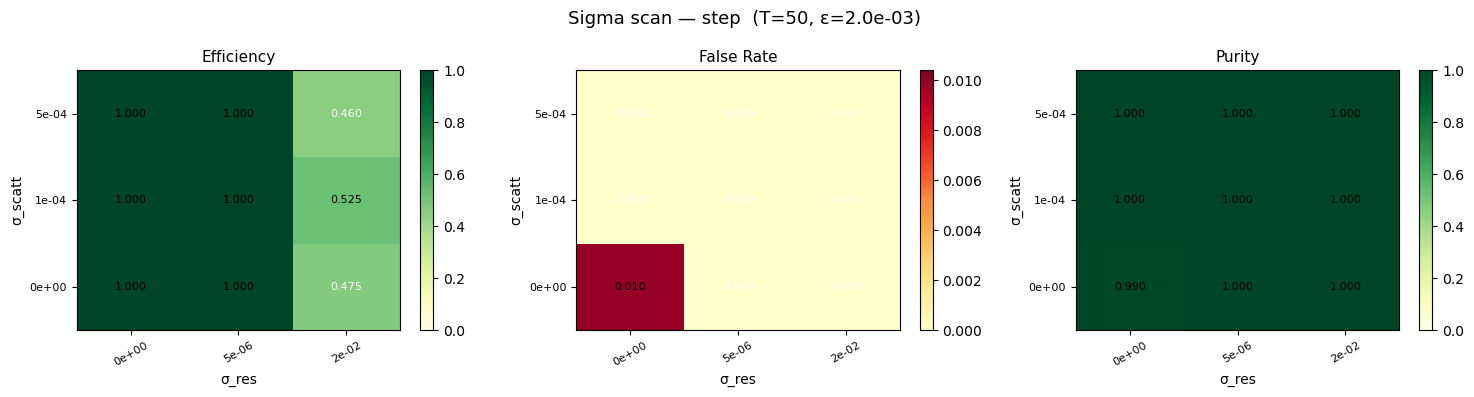

Saved sigma_scan_heatmap_step.png


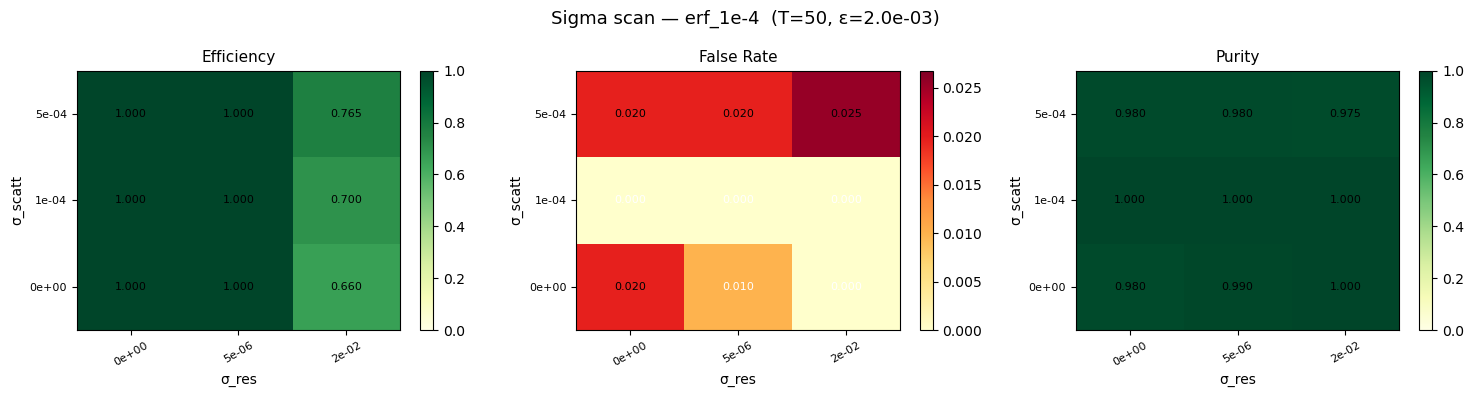

Saved sigma_scan_heatmap_erf_1e-4.png


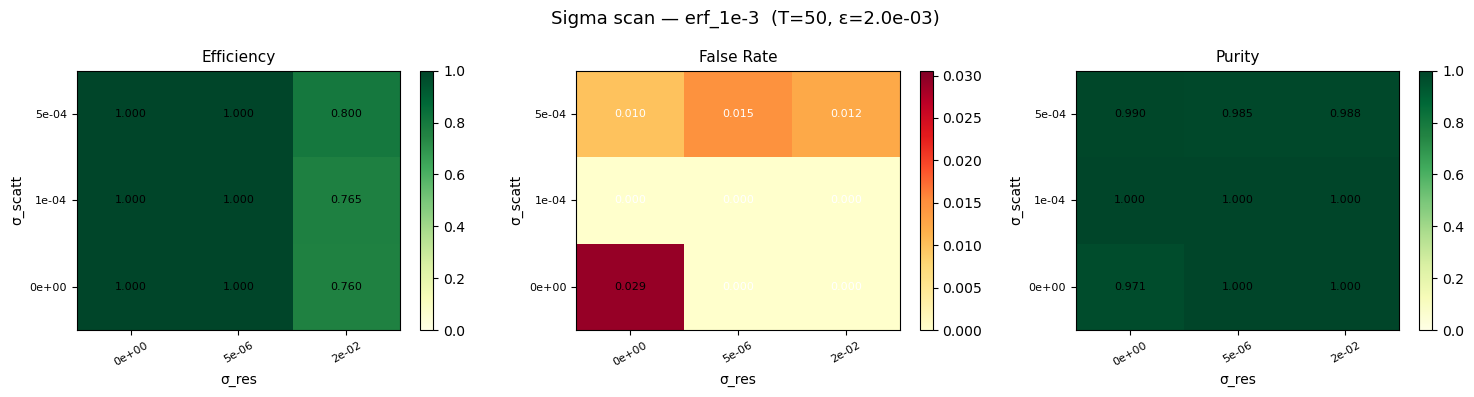

Saved sigma_scan_heatmap_erf_1e-3.png


In [13]:
# =============================================================
# §3b  Heatmaps  — efficiency / FAR / purity per Hamiltonian
# =============================================================
import matplotlib.ticker as mticker

ns = len(SIGMA_SCATT_VALS)
nr = len(SIGMA_RES_VALS)

def _make_grid(ham_key, metric_key):
    g = np.zeros((ns, nr))
    for i, ss in enumerate(SIGMA_SCATT_VALS):
        for j, sr in enumerate(SIGMA_RES_VALS):
            g[i, j] = metrics_scan[(ss, sr, ham_key)][metric_key]
    return g

ss_labels = [f'{v:.0e}' for v in SIGMA_SCATT_VALS]
sr_labels = [f'{v:.0e}' for v in SIGMA_RES_VALS]

metric_configs = [
    ('segment_efficiency', 'Efficiency',  plt.cm.YlGn,  (0, 1)),
    ('segment_false_rate', 'False Rate',  plt.cm.YlOrRd,(0, None)),
    ('segment_purity',     'Purity',      plt.cm.YlGn,  (0, 1)),
]

for ham_key, _, _ in SCAN_HAMS:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Sigma scan — {ham_key}  (T={T}, ε={EPSILON:.1e})', fontsize=13)

    for ax, (mk, mlabel, cmap, vlim) in zip(axes, metric_configs):
        grid = _make_grid(ham_key, mk)
        vmin = vlim[0]
        vmax = vlim[1] if vlim[1] is not None else float(grid.max()) * 1.05

        im = ax.imshow(grid, cmap=cmap, vmin=vmin, vmax=vmax,
                       aspect='auto', origin='lower')
        plt.colorbar(im, ax=ax)
        ax.set_xticks(range(nr)); ax.set_xticklabels(sr_labels, rotation=30, fontsize=8)
        ax.set_yticks(range(ns)); ax.set_yticklabels(ss_labels, fontsize=8)
        ax.set_xlabel('σ_res', fontsize=10)
        ax.set_ylabel('σ_scatt', fontsize=10)
        ax.set_title(mlabel, fontsize=11)
        # annotate cells
        for i in range(ns):
            for j in range(nr):
                ax.text(j, i, f'{grid[i,j]:.3f}', ha='center', va='center',
                        fontsize=8,
                        color='white' if grid[i,j] < (vmin+vmax)/2 else 'black')

    plt.tight_layout()
    fname = f'sigma_scan_heatmap_{ham_key}.png'
    fig.savefig(FIGURES / fname, dpi=150, bbox_inches='tight')
    fig.savefig(FIGURES / fname.replace('.png','.pdf'), bbox_inches='tight')
    plt.show()
    print(f"Saved {fname}")


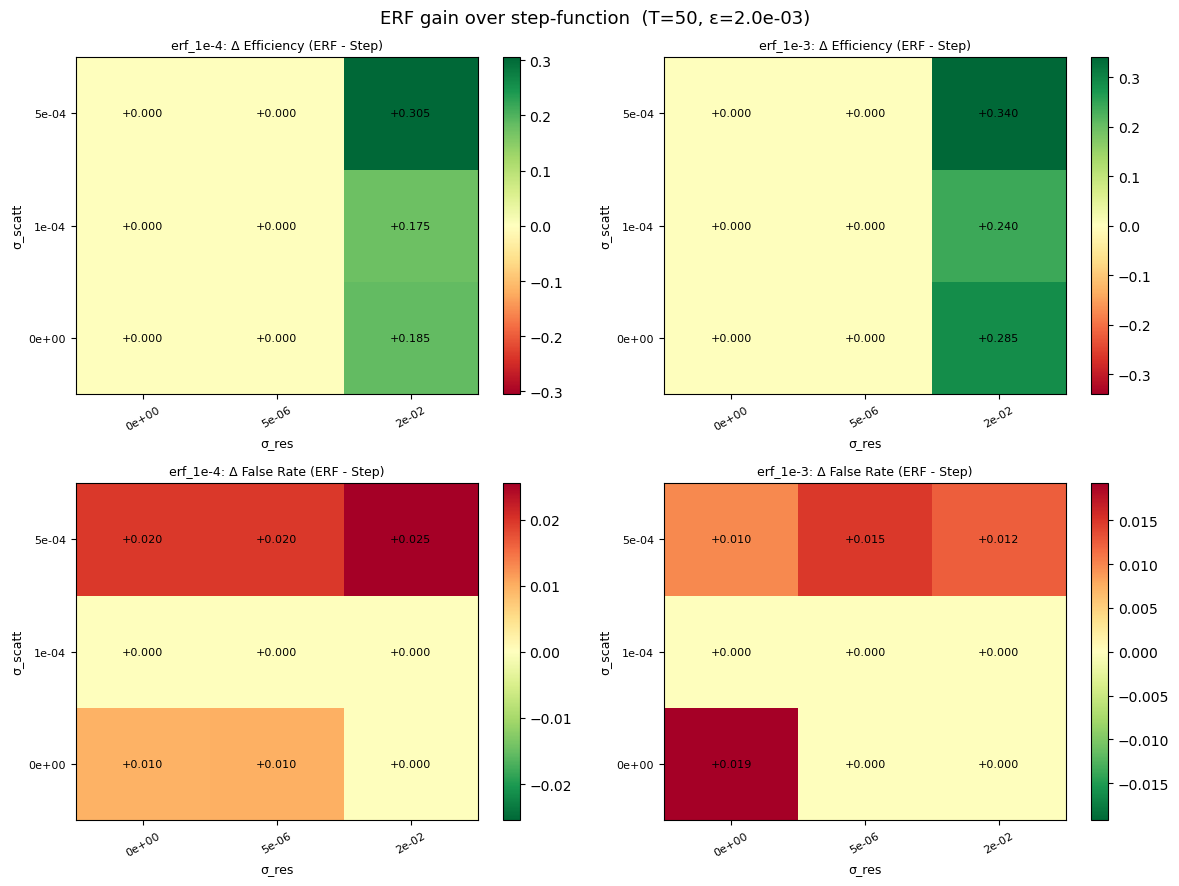

Saved sigma_scan_delta.png

All figures complete:
  A_heatmap_td_comparison.png
  activation_scatter_T_vs_td.png
  activation_sorted_T10.png
  angle_dist_erf_overlay.png
  eigspectrum_noise_delta.png
  eigspectrum_step_vs_erf_clean.png
  eigspectrum_summary.png
  ham_structure_vs_td.png
  kappa_vs_td_clean.png
  quantum_comparison_clean_T10.png
  score_spectrum_by_td.png
  seg_metrics_clean.png
  seg_metrics_noisy.png
  seg_metrics_ss0.0001_sr0.png
  seg_metrics_ss0.0003_sr0.01.png
  seg_metrics_ss0.0005_sr0.02.png
  sigma_scan_delta.png
  sigma_scan_heatmap_erf_1e-3.png
  sigma_scan_heatmap_erf_1e-4.png
  sigma_scan_heatmap_step.png
  sol_classical_clean.png
  youden_eer_vs_td.png


In [14]:
# =============================================================
# §3c  ERF gain over step  (Δmetric heatmaps)
# =============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle(f'ERF gain over step-function  (T={T}, ε={EPSILON:.1e})', fontsize=13)

for col, erf_key in enumerate(['erf_1e-4', 'erf_1e-3']):
    for row, (mk, mlabel, cmap) in enumerate([
            ('segment_efficiency', 'Δ Efficiency (ERF - Step)',  plt.cm.RdYlGn),
            ('segment_false_rate', 'Δ False Rate (ERF - Step)',  plt.cm.RdYlGn_r)]):
        delta = _make_grid(erf_key, mk) - _make_grid('step', mk)
        lim = float(np.abs(delta).max()) + 1e-6
        im = axes[row, col].imshow(delta, cmap=cmap, vmin=-lim, vmax=lim,
                                    aspect='auto', origin='lower')
        plt.colorbar(im, ax=axes[row, col])
        axes[row, col].set_xticks(range(nr)); axes[row, col].set_xticklabels(sr_labels, rotation=30, fontsize=8)
        axes[row, col].set_yticks(range(ns)); axes[row, col].set_yticklabels(ss_labels, fontsize=8)
        axes[row, col].set_xlabel('σ_res', fontsize=9)
        axes[row, col].set_ylabel('σ_scatt', fontsize=9)
        axes[row, col].set_title(f'{erf_key}: {mlabel}', fontsize=9)
        for i in range(ns):
            for j in range(nr):
                axes[row, col].text(j, i, f'{delta[i,j]:+.3f}', ha='center',
                                    va='center', fontsize=8)

plt.tight_layout()
fig.savefig(FIGURES / 'sigma_scan_delta.png', dpi=150, bbox_inches='tight')
fig.savefig(FIGURES / 'sigma_scan_delta.pdf', bbox_inches='tight')
plt.show()
print("Saved sigma_scan_delta.png")
print("\nAll figures complete:")
for f in sorted(FIGURES.glob('*.png')):
    print(f"  {f.name}")
